# Titanic - Machine Learning from Disaster

**Objective**: Predict passenger survival on the Titanic using machine learning through cleaning, and feature analysis, and model training

**Data Source**: [Kaggle: Titanic - Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

**Inspired and modified in accordance with**: [Titanic - Advanced Feature Engineering Tutorial](https://www.kaggle.com/code/gunesevitan/titanic-advanced-feature-engineering-tutorial#3.-Model)

## Packages installation and libraries importation

In [1]:
pip install pandas numpy matplotlib seaborn torch scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Some common libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis

### Data overview

In [3]:
df_train = pd.read_csv('../data/raw/train.csv')
print(f"Initial dataset shape: {df_train.shape}")
print(df_train.shape)
print(df_train.info())
df_train.head()

Initial dataset shape: (891, 12)
(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df_test = pd.read_csv('../data/raw/test.csv')
print(f"Test dataset shape: {df_test.shape}")
print(df_test.shape)
print(df_test.info())
df_test.head()

Test dataset shape: (418, 11)
(418, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
None


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
df_train = df_train.drop(['PassengerId'], axis=1)

- Survived:
    + 1: Survived
    + 0: Not survived

- Pclass: A proxy for socio-economic status (SES)
    + 1st = Upper
    + 2nd = Middle
    + 3rd = Lower

- Age: Age is fractional if less than 1, it in the form of x.5 if estimated

- Sibsp:
    + Sibling = brother, sister, stepbrother, stepsister
    + Spouse = husband, wife (mistresses and fiances were ignored)

- Parch:
    + Parent = mother, father
    + Child = daughter, son, stepdaughter, stepson
    + Some children travelled only with a nanny, therefore parch=0 for them.

- Ticket: Families or groupes had purchased tickets together shared the same ticket number. However, they tickets can be different if there were multiple transactions.

- Fare: The price of ticket, can be associated with family size

- Cabin: Range from A-G with 80% missing values

- Embarked: Where the passengers boarded the ship: Cherbourg, Queenstown, Southampton

### Plot functions

In [6]:
def group_by_col_and_plot(df, col):
    gr = df.groupby(col, observed=False).size().to_frame(name='Count')
    gr['Ratio'] = np.round(gr['Count'] / gr['Count'].sum() * 100, 0)
    
    print(f'Total number of {col}: {gr["Count"].sum()}')
    
    colors = sns.color_palette(n_colors=len(gr))
    
    # Create subplots
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Bar chart
    gr['Count'].plot(kind='bar', ax=ax1, color=colors, title=f'{col} Counts')
    ax1.set_xlabel('')
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=0)
    
    # Pie chart
    gr['Ratio'].plot(kind='pie', ax=ax2, colors=colors, title=f'{col} Ratio', autopct='%1.1f%%', ylabel='')   

    plt.tight_layout()
    plt.show()
    

In [11]:
from scipy import stats
def is_significant(gr, threshold=0.05):
    # Chi-Square Test
    chi2, p, _, _ = stats.chi2_contingency(gr)
    
    # Cramer's V Calculation
    n = gr.sum().sum()
    min_dim = min(gr.shape[0], gr.shape[1]) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    
    # Interpretation
    if cramers_v <= 0.2:
        strength = "weak"
    elif cramers_v <= 0.6:
        strength = "moderate"
    else:
        strength = "strong"

    if p < threshold:
        print(f"Result: statistically significant (p = {p:.5e})")
        print(f"Correlation (Cramér's V): {cramers_v:.3f} ({strength} association)")
    else:
        print(f"Result: statistically insignificant (p = {p:.5e})")
        print(f"Correlation (Cramér's V): {cramers_v:.3f} ({strength} association)")
    

def group_by_2_cols(df, col_1, col_2):
    gr = df.groupby([col_1, col_2], observed=False).size().unstack(col_1, fill_value=0)
    print(gr)
    
    return gr

def plot_2_cols_chart(gr, col_1, col_2):
    gr_total = gr.sum(axis=1)
    gr = np.round(gr.divide(gr_total, axis=0) * 100, 2)
    gr_total_percentage = np.round((gr_total/gr_total.sum())*100, 2)
    
    colors = sns.color_palette(n_colors=sum(gr.nunique()))
    
    # Create subplots
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Bar chart
    gr.plot(kind='bar', ax=ax1, color=colors, title=f'Proportion of {col_1} per {col_2}')
    
    for container in ax1.containers:
        ax1.bar_label(container, fmt='%.2f')
    
    ax1.set_xlabel('')
    ax1.set_ylabel('%', rotation=1)
    ax1.tick_params(axis='x', rotation=0)
    
    # Pie chart
    gr_total_percentage.plot(kind='pie', ax=ax2, colors=colors, title=f'{col_1} Ratio', autopct='%1.1f%%', ylabel='')  

    plt.tight_layout()
    plt.show()
    
    return

### Sex

Total number of Sex: 891


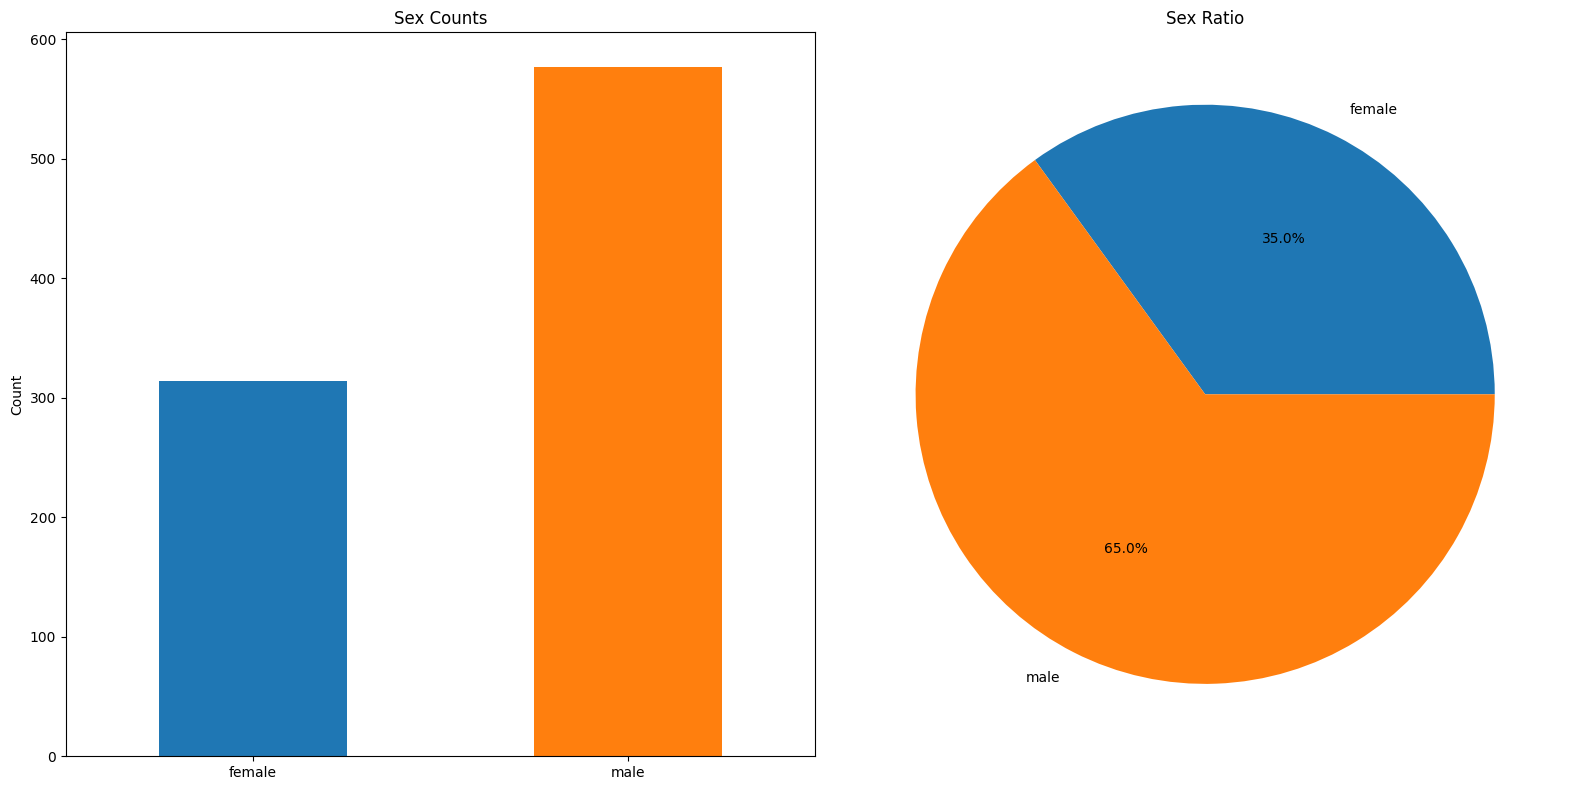

In [8]:
group_by_col_and_plot(df_train, col='Sex')

Survived    0    1
Sex               
female     81  233
male      468  109


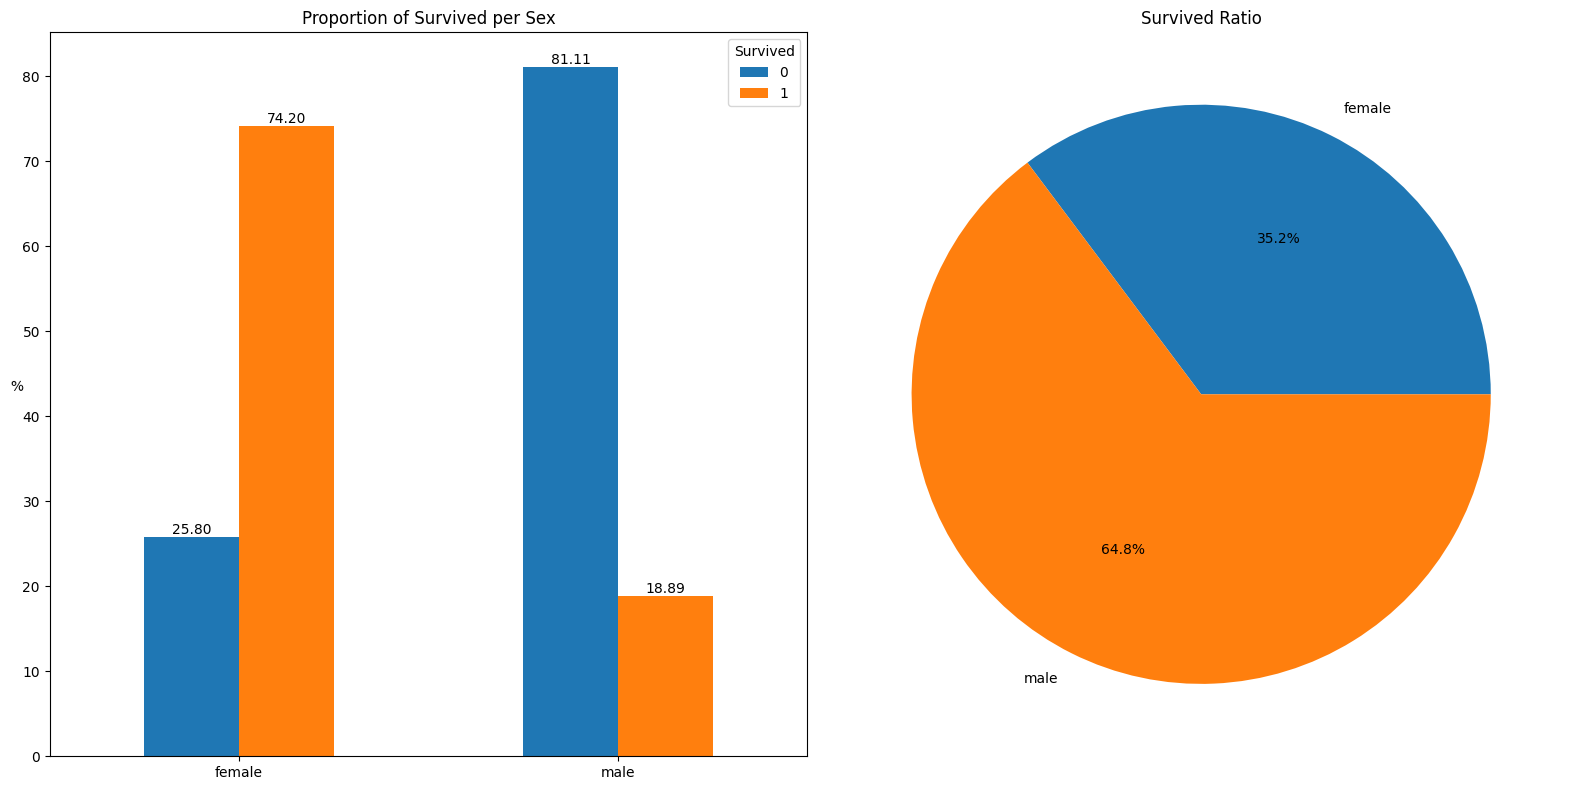

Result: STATISTICALLY SIGNIFICANT (p = 1.19736e-58)
Correlation (Cramér's V): 0.541 (moderate association)


In [10]:
gr = group_by_2_cols(df_train, col_1='Survived', col_2='Sex')
plot_2_cols_chart(gr, col_1='Survived', col_2='Sex')
is_significant(gr)

Gender was the dominant predictor of survival with females had a 74.2% survival rate while males had only an 18.9% survival rate.

### Age

In [14]:
age_by_pclass_sex = df_train.groupby(['Sex', 'Pclass'])['Age'].median()

for pclass in range(1, 4):
    for sex in ['female', 'male']:
        print('Median age of Pclass {} {}s: {}'.format(pclass, sex, age_by_pclass_sex[sex][pclass]))
print('Median age of all passengers: {}'.format(df_train['Age'].median()))

Median age of Pclass 1 females: 35.0
Median age of Pclass 1 males: 40.0
Median age of Pclass 2 females: 28.0
Median age of Pclass 2 males: 30.0
Median age of Pclass 3 females: 21.5
Median age of Pclass 3 males: 25.0
Median age of all passengers: 28.0


<Axes: ylabel='Density'>

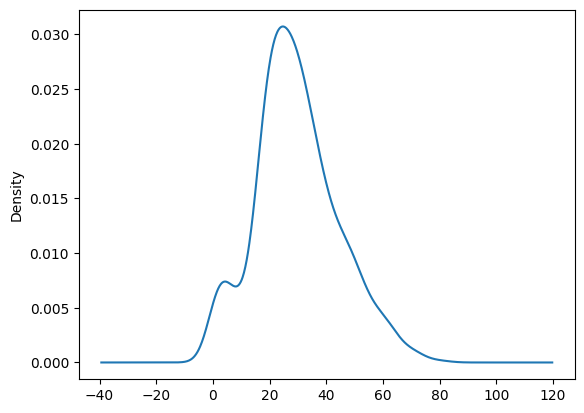

In [ ]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(20, 20))
plt.subplots_adjust(right=1.5)

# Distribution of survival in feature
sns.distplot(df_train[~surv][feature], label='Not Survived', hist=True, color='#e74c3c', ax=axs[0][i])
sns.distplot(df_train[surv][feature], label='Survived', hist=True, color='#2ecc71', ax=axs[0][i])
    
# Distribution of feature in dataset
sns.distplot(df_train[feature], label='Training Set', hist=False, color='#e74c3c', ax=axs[1][i])
sns.distplot(df_test[feature], label='Test Set', hist=False, color='#2ecc71', ax=axs[1][i])
    
axs[0][i].set_xlabel('')
axs[1][i].set_xlabel('')
    
for j in range(2):        
    axs[i][j].tick_params(axis='x', labelsize=20)
    axs[i][j].tick_params(axis='y', labelsize=20)
    
axs[0][i].legend(loc='upper right', prop={'size': 20})
axs[1][i].legend(loc='upper right', prop={'size': 20})
axs[0][i].set_title('Distribution of Survival in {}'.format(feature), size=20, y=1.05)

axs[1][0].set_title('Distribution of {} Feature'.format('Age'), size=20, y=1.05)
axs[1][1].set_title('Distribution of {} Feature'.format('Fare'), size=20, y=1.05)
        
plt.show()

### Fare

### Embarked

### Name

Names are in the format of {Last Name}, {Title}. {First Name}. It would be useful to extract the titles and last names to gain information about classes and family relations

In [108]:
def extract_title_and_last_name(name: str):
    if not name or not name.strip():
        return None, None
    
    parts = name.split(', ')
    
    last_name = parts[0] if len(parts) > 0 else None  # Remove last char
    title = parts[1].split('. ')[0] if len(parts) > 1 else None
    
    return title, last_name
df_train[['Title', 'Lastname']] = df_train['Name'].apply(lambda x: pd.Series(extract_title_and_last_name(x)))
df_train = df_train.drop(['Name'], axis=1)
df_train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Lastname
0,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,Braund
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,Cumings
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,Heikkinen
3,1,1,female,35.0,1,0,113803,53.1000,C123,S,Mrs,Futrelle
4,0,3,male,35.0,0,0,373450,8.0500,NaN,S,Mr,Allen


Total number of Title: 891


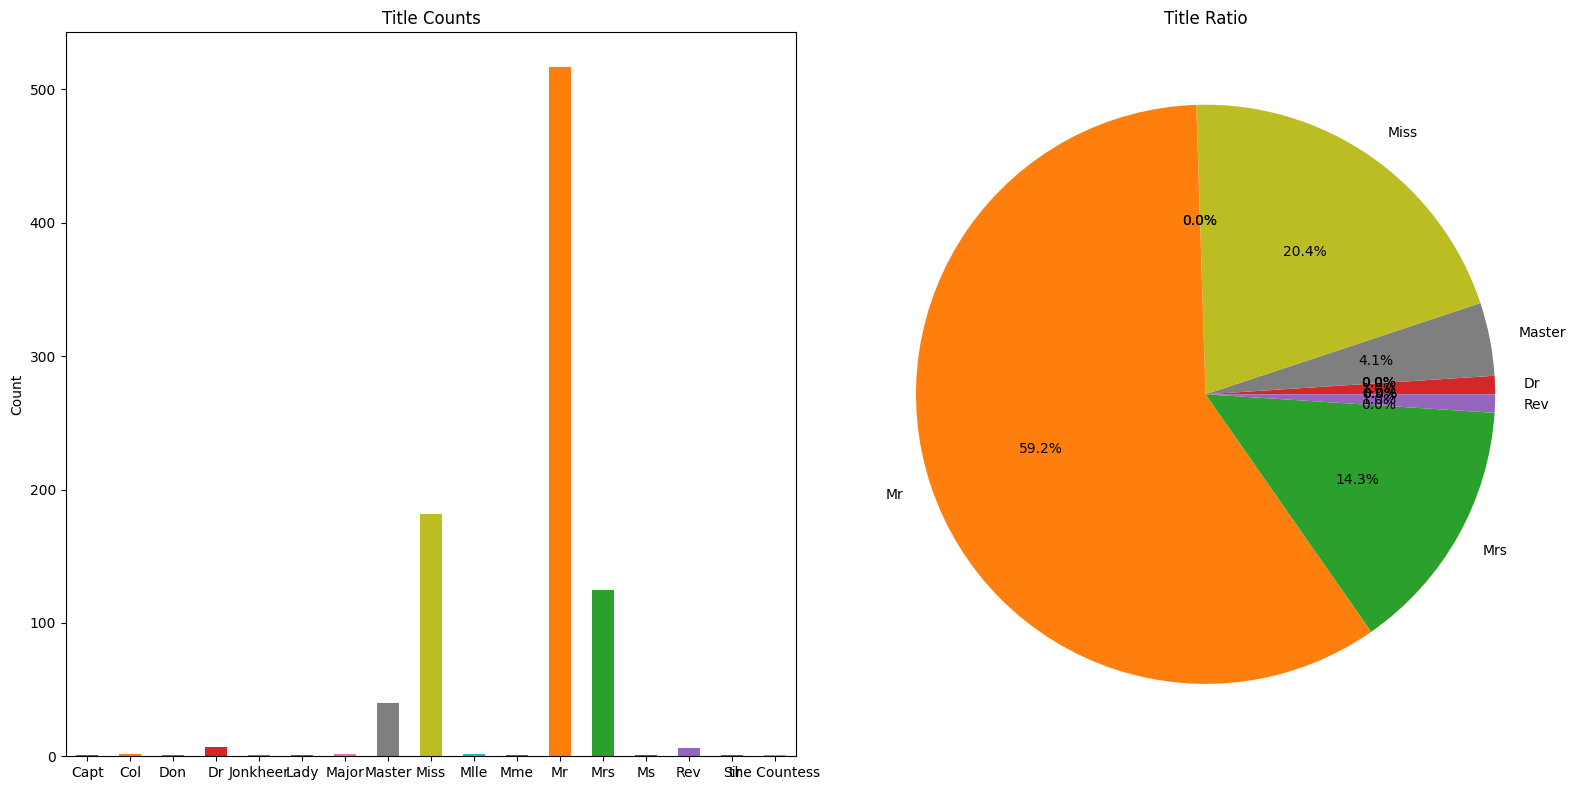

In [109]:
group_by_col_and_plot(df_train, 'Title')

Survived        0    1
Title                 
Academic        4    3
Master         17   23
Military        3    2
Miss           55  130
Mr            436   81
Mrs            26  100
Noble           2    1
Noble_Female    0    2
Religious       6    0


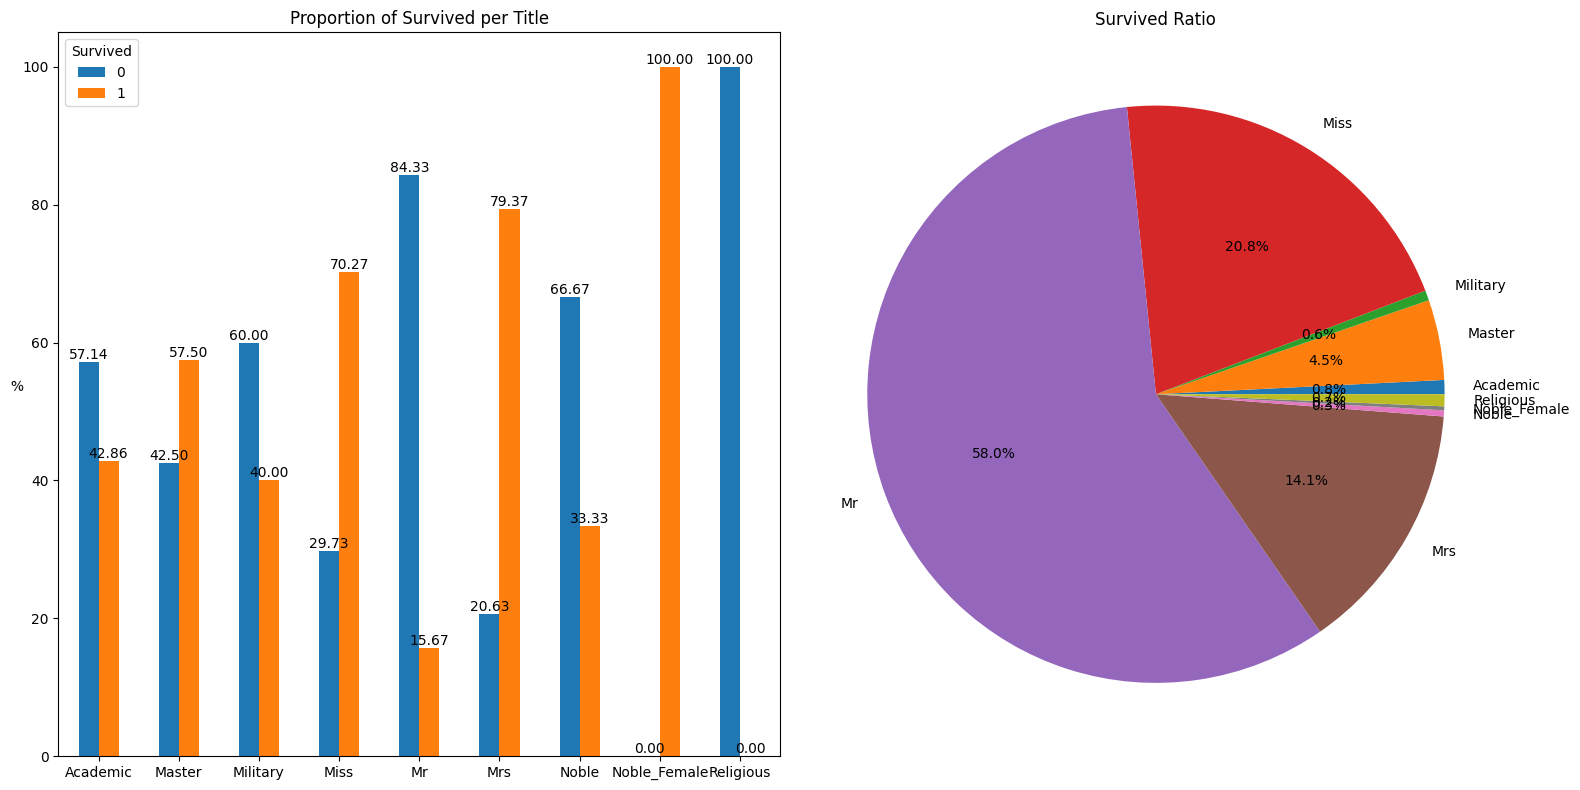

Result: STATISTICALLY SIGNIFICANT (p = 4.68467e-59)
Correlation (Cramér's V): 0.575 (moderate association)


In [93]:
gr = group_by_2_cols(df_train, col_1='Survived', col_2='Title')
plot_2_cols_chart(gr, col_1='Survived', col_2='Title')
is_significant(gr)

It seems that Master, Miss, Mrs, and Noble_Female titles are titles strongly correlated to Survived

### Family Size

Combine SibSp and Parch as FamilySize

FamilySize = SibSp + Parch + 1 to account for all members in the family including the person we are looking at

In [99]:
def create_family_size(df):
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df.drop(['SibSp', 'Parch'], axis=1)

    return df

df_train = create_family_size(df_train)
df_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Lastname,FamilySize
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,Braund,2
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,Cumings,2
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,Heikkinen,1
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S,Mrs,Futrelle,2
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S,Mr,Allen,1


Total number of Title: 891


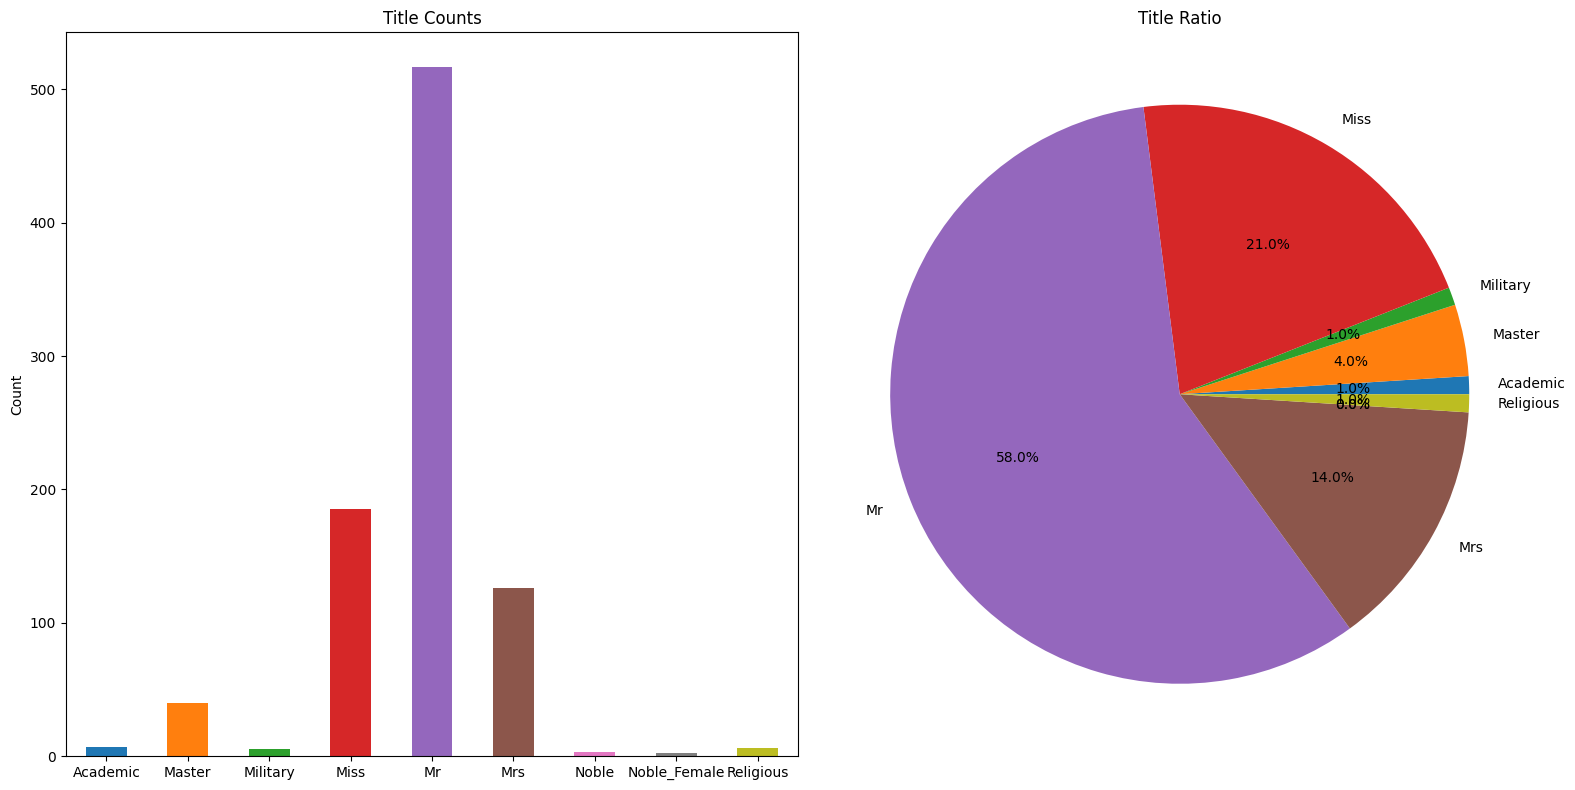

In [96]:
group_by_col_and_plot(df_train, 'Title')

By bivariate analysis of the statistically significant columns with the survivors:

- By age, infants are more likely to survive, while the opposite are more likely to seniors
- By family size, people with family size from 2-4 is more likely to survive
- By PClass, upper class is more likely to survive, while lower class is the opposite
- By sex, female is more likely to survive than male

Can group infants with female is a strong indicator of survival rate, and family size 2-4 with PClass upper as a moderately strong indicator.

## Feature Engineering

Map title to their correspondences in English

In [ ]:
title_mapping = {
    'Mr': 'Mr',
    'Mrs': 'Mrs',
    'Miss': 'Miss',
    'Ms': 'Miss',
    'Master': 'Master',
    'Mme': 'Mrs',     # French for Mrs
    'Mlle': 'Miss',   # French for Miss
    'the Count': 'Noble',
    'the Countess': 'Noble_Female',
    'Count': 'Noble',
    'Coutess': 'Noble_Female',
    'Don': 'Noble',   # Not a Knight
    'Sir': 'Noble',   # Knight
    'Jonkheer': 'Noble',
    'Jonkvrouw': 'Noble_Female',
    'Earl': 'Noble',
    'Lord': 'Noble',
    'Lady': 'Noble_Female',
    'Dame': 'Noble_Female',
    'Major': 'Military',
    'Col': 'Military',
    'Capt': 'Military',
    'Dr': 'Academic',
    'Prof': 'Academic',
    'Rev': 'Religious'
}
def map_title(df: pd.DataFrame):
    df['Title'] = df['Title'].map(title_mapping)
    
df_train['Title'] = df_train['Name'].apply(lambda x: pd.Series(map_title(x)))

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,FamilySize,Title,LastName
0,1,No,Lower,"Braund, Mr. Owen Harris",male,Adult,A/5 21171,7.2500,NaN,Southampton,2,Mr,Braund
1,2,Yes,Upper,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,Adult,PC 17599,71.2833,C85,Cherbourg,2,Mrs,Cumings
2,3,Yes,Lower,"Heikkinen, Miss. Laina",female,Adult,STON/O2. 3101282,7.9250,NaN,Southampton,1,Miss,Heikkinen
3,4,Yes,Upper,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,Adult,113803,53.1000,C123,Southampton,2,Mrs,Futrelle
4,5,No,Lower,"Allen, Mr. William Henry",male,Adult,373450,8.0500,NaN,Southampton,1,Mr,Allen


Survived              No  Yes
is_infant_or_female          
False                460  103
True                  89  239


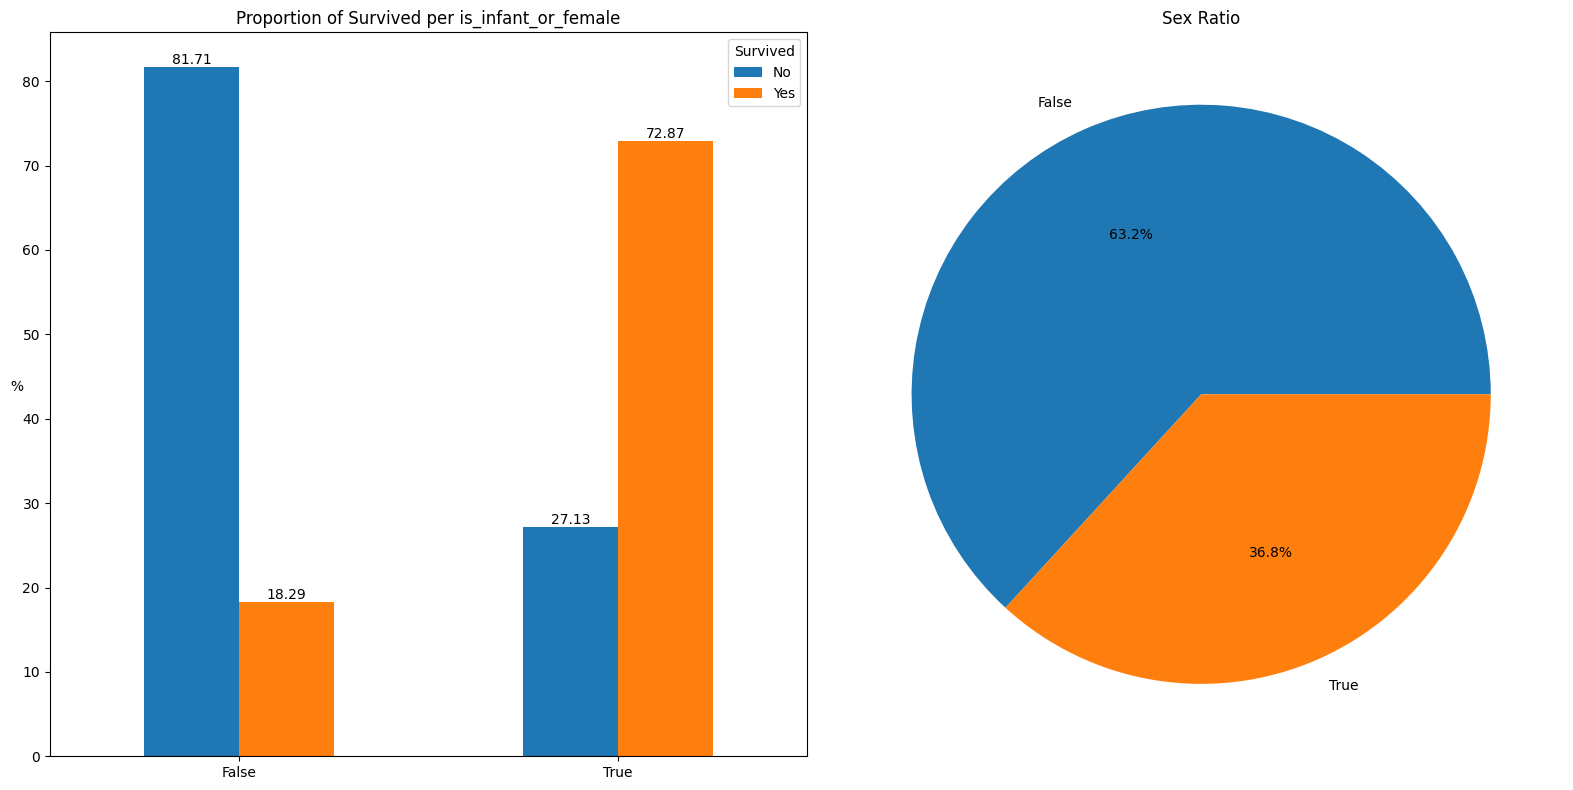

The columns are statistically significant with p_value = 3.354319128434374e-58


In [22]:
df['is_infant_or_female'] = ((df['Age'] == 'Child') | (df['Sex'] == 'female')).astype('category')

gr = group_by_2_cols(df, col_1='Survived', col_2='is_infant_or_female')
plot_2_cols_chart(gr, col_1='Survived', col_2='is_infant_or_female')
is_df_significant(gr, threshold=0.0001)

In [23]:
df['FamilyID'] = df['LastName'] + df['FamilySize'].astype(str)
df['ClassPortID'] = df['Pclass'] + df['Embarked']
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,FamilySize,Title,LastName,is_infant_or_female,FamilyID,ClassPortID
0,1,No,Lower,"Braund, Mr. Owen Harris",male,Adult,A/5 21171,7.2500,NaN,Southampton,2,Mr,Braund,False,Braund2,LowerSouthampton
1,2,Yes,Upper,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,Adult,PC 17599,71.2833,C85,Cherbourg,2,Mrs,Cumings,True,Cumings2,UpperCherbourg
2,3,Yes,Lower,"Heikkinen, Miss. Laina",female,Adult,STON/O2. 3101282,7.9250,NaN,Southampton,1,Miss,Heikkinen,True,Heikkinen1,LowerSouthampton
3,4,Yes,Upper,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,Adult,113803,53.1000,C123,Southampton,2,Mrs,Futrelle,True,Futrelle2,UpperSouthampton
4,5,No,Lower,"Allen, Mr. William Henry",male,Adult,373450,8.0500,NaN,Southampton,1,Mr,Allen,False,Allen1,LowerSouthampton


In [24]:
print(df['Title'].unique())
df.loc[df['FamilyID'] == 'Braund2']

['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'the Countess' 'Jonkheer']


,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,FamilySize,Title,LastName,is_infant_or_female,FamilyID,ClassPortID
0,1,No,Lower,"Braund, Mr. Owen Harris",male,Adult,A/5 21171,7.2500,NaN,Southampton,2,Mr,Braund,False,Braund2,LowerSouthampton
477,478,No,Lower,"Braund, Mr. Lewis Richard",male,Adult,3460,7.0458,NaN,Southampton,2,Mr,Braund,False,Braund2,LowerSouthampton


In [25]:
df['FamilySize'] = pd.cut(df['FamilySize'], bins=[0, 1, 4, 15], labels=['Solo', 'Average', 'Large'])

Survived     No  Yes
FamilySize          
Solo        374  163
Average     123  169
Large        52   10


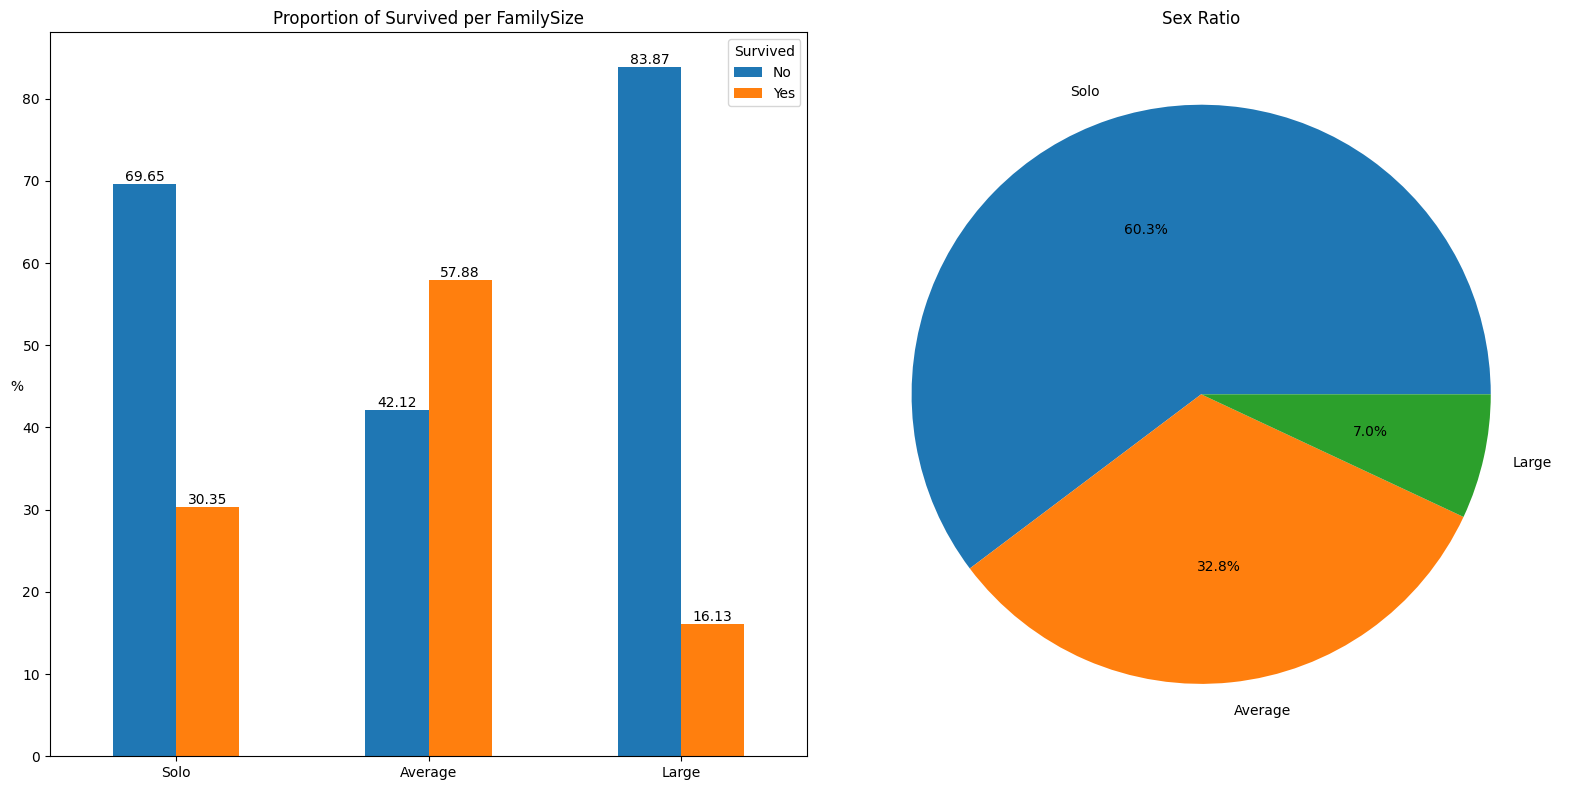

The columns are statistically significant with p_value = 6.522919536640473e-17


In [26]:
gr = group_by_2_cols(df, col_1='Survived', col_2='FamilySize')
plot_2_cols_chart(gr, col_1='Survived', col_2='FamilySize')
is_df_significant(gr, threshold=0.0001)

Pclass       Lower  Middle  Upper
Embarked                         
Cherbourg       66      17     85
Queenstown      72       3      2
Southampton    353     164    127


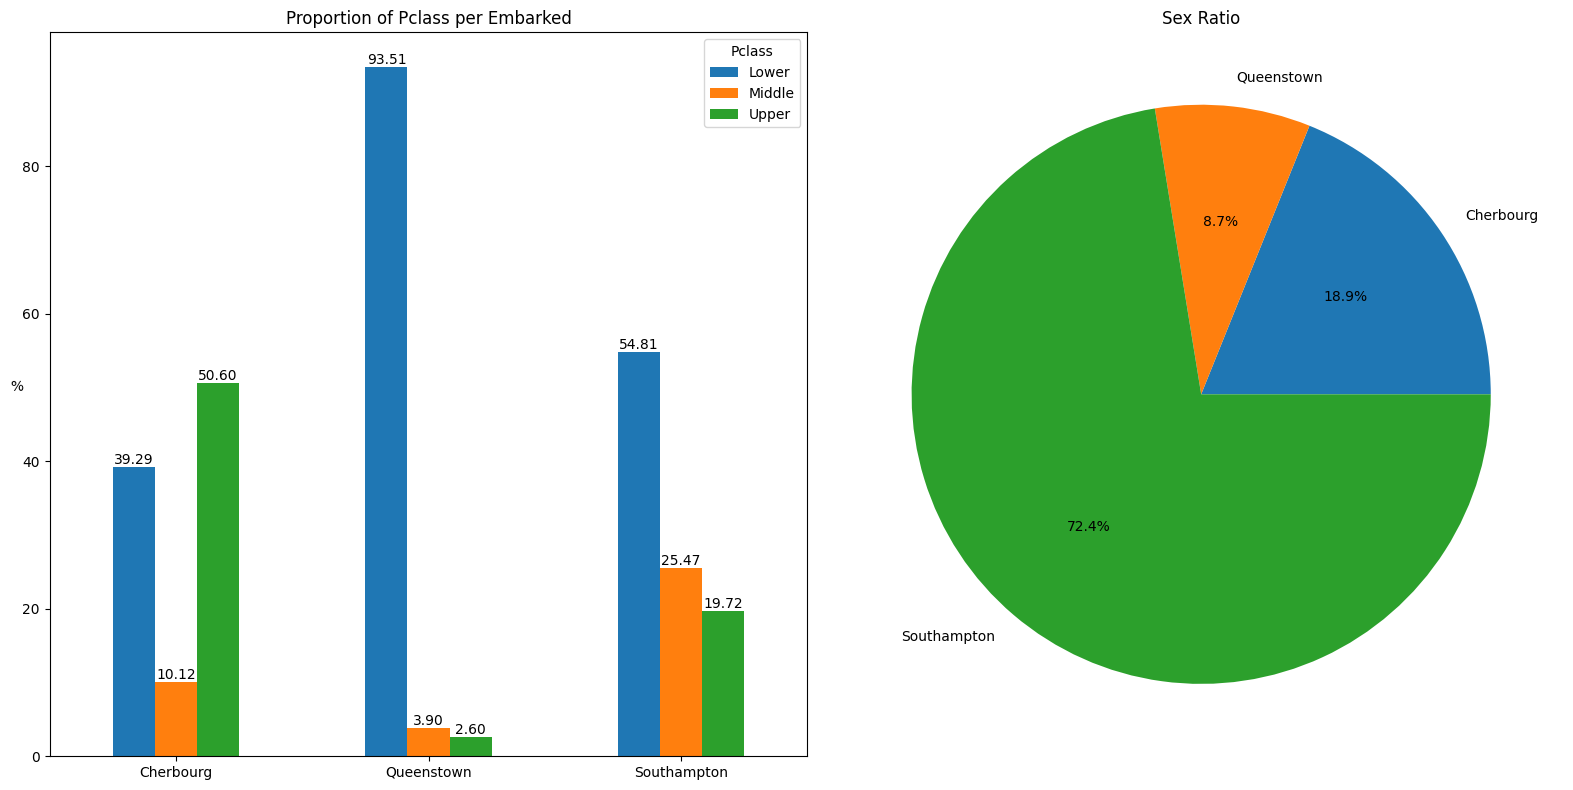

The columns are statistically significant with p_value = 8.435267819894384e-26
Survived      No  Yes
Embarked             
Cherbourg     75   93
Queenstown    47   30
Southampton  427  217


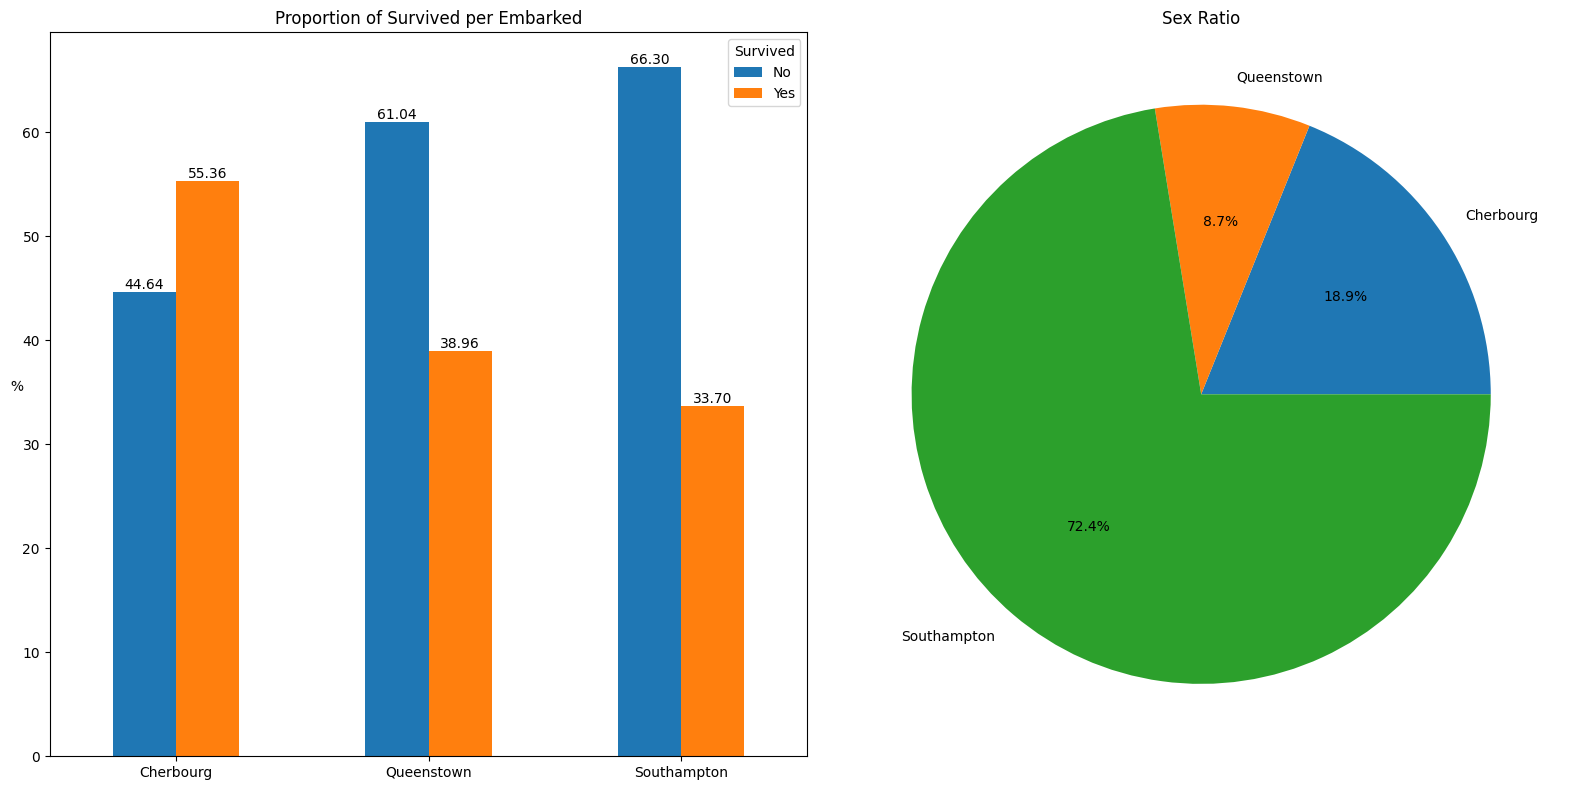

The columns are statistically significant with p_value = 1.769922284120912e-06
Survived   No  Yes
Pclass            
Lower     372  119
Middle     97   87
Upper      80  136


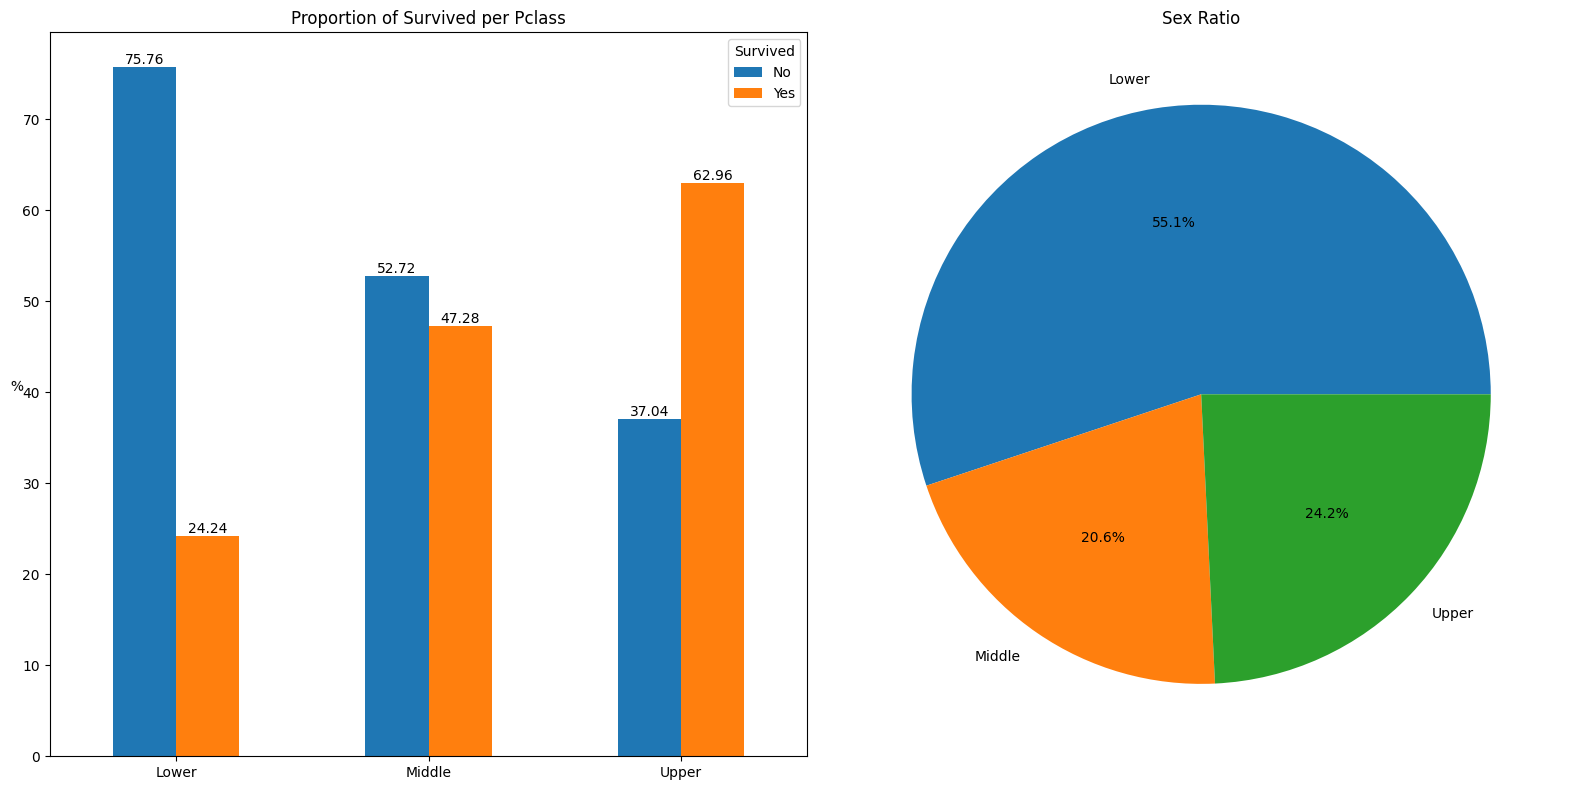

The columns are statistically significant with p_value = 4.5492517112987287e-23


In [27]:
gr = group_by_2_cols(df, col_1='Pclass', col_2='Embarked')
plot_2_cols_chart(gr, col_1='Pclass', col_2='Embarked')
is_df_significant(gr, threshold=0.0001)

gr = group_by_2_cols(df, col_1='Survived', col_2='Embarked')
plot_2_cols_chart(gr, col_1='Survived', col_2='Embarked')
is_df_significant(gr, threshold=0.0001)

gr = group_by_2_cols(df, col_1='Survived', col_2='Pclass')
plot_2_cols_chart(gr, col_1='Survived', col_2='Pclass')
is_df_significant(gr, threshold=0.0001)

In [28]:
# Filter rows where 'class' is 'upper', then sort by 'fare' in descending order
sorted_df = df[(df['Pclass'] == 'Lower') & (df['Survived'] == 'Yes')].sort_values(by='Fare', ascending=True)  
print(sorted_df)

     PassengerId Survived Pclass                               Name     Sex  \
271          272      Yes  Lower       Tornquist, Mr. William Henry    male   
804          805      Yes  Lower            Hedman, Mr. Oskar Arvid    male   
127          128      Yes  Lower          Madsen, Mr. Fridtjof Arne    male   
19            20      Yes  Lower            Masselmani, Mrs. Fatima  female   
553          554      Yes  Lower  Leeni, Mr. Fahim ("Philip Zenni")    male   
..           ...      ...    ...                                ...     ...   
74            75      Yes  Lower                      Bing, Mr. Lee    male   
509          510      Yes  Lower                     Lang, Mr. Fang    male   
643          644      Yes  Lower                    Foo, Mr. Choong    male   
692          693      Yes  Lower                       Lam, Mr. Ali    male   
838          839      Yes  Lower                    Chip, Mr. Chang    male   

       Age   Ticket     Fare Cabin     Embarked Fam

## Fill missing values

In [29]:
df = pd.read_csv('../data/raw/train.csv')
df['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [30]:
df.sort_values('Fare')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
815,816,0,1,"Fry, Mr. Richard",male,NaN,0,0,112058,0.0000,B102,S
806,807,0,1,"Andrews, Mr. Thomas Jr",male,39.0,0,0,112050,0.0000,A36,S
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0000,NaN,S
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0000,NaN,S
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0000,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C


In [31]:
df = pd.read_csv('../data/raw/train.csv')
df[df['Pclass'] == 3]['Cabin'].isna()

0      True
2      True
4      True
5      True
7      True
       ... 
882    True
884    True
885    True
888    True
890    True
Name: Cabin, Length: 491, dtype: bool

In [43]:

import mlflow
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, recall_score, f1_score

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare features for training:
    - drop Name, Ticket, Fare, and Cabin
    - fill missing cells of Age and Embarke
    - combine SibSp and Parch into 1 column FamilySize
    - split age to 5 groups: Infant, child, Teenager, Adult, and Senior (0-4)
    - encode categorical columns: Sex, Embarked, PClass
    - add 2 significant indicators: is_infant_or_female, is_family_size_2_to_4_or_upper_class
    """
    
    df[['Title', 'LastName']] = df['Name'].apply(lambda x: pd.Series(extract_title_and_last_name(x))).astype('category')
    
    # Standardize titles
    title_mapping = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
    df['Title'] = df['Title'].map(title_mapping)

    # Create mask for title replacement
    title_mask = ~df['Title'].isin(['Mr', 'Miss', 'Mrs', 'Master'])
    df.loc[title_mask, 'Title'] = df.loc[title_mask, 'Sex'].map({'male': 'Mr', 'female': 'Mrs'})
    df['Title'] = df['Title'].astype('category')
    df['Title'] = df['Title'].map({'Miss': 0, 'Mrs': 1, 'Master': 2, 'Mr': 3}).astype(int)
    
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['Fare'] = df['Fare'] * df['FamilySize'].astype(float)
    
    df['FamilySize'] = (pd.cut(df['FamilySize'], bins=[0, 2, 5, np.inf], labels=['Solo', 'Average', 'Large']))
    df['FamilyID'] = df['LastName'].astype(str) + df['FamilySize'].astype(str)
    df['FamilySize'] = df['FamilySize'].map({'Average': 0, 'Solo': 1, 'Large': 2}).astype(int)
    
    df = df.fillna({'Age': df.groupby(['Title', 'Pclass'], observed=False)['Age'].transform('median')})
    df = df.fillna({'Embarked': df.groupby(['FamilyID', 'Pclass'], observed=False)['Embarked'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    df = df.fillna({'Embarked': df.groupby(['Pclass'], observed=False)['Embarked'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    df = df.fillna({'Cabin': df.groupby(['FamilyID', 'Pclass'], observed=False)['Cabin'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    df = df.fillna({'Cabin': df.groupby(['Pclass', 'Embarked'], observed=False)['Cabin'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    df = df.fillna({'Cabin': df.groupby(['Pclass'], observed=False)['Cabin'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    
    if 'Sex' in df.columns:
        df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2}).astype(int)
    df['Cabin'] = df['Cabin'].map(lambda x: ord(x[0]) - ord('A')).astype(int)
    if 'Pclass' in df.columns:
        df['Pclass'] = df['Pclass'] - 1
    
    df = df.drop(['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'LastName', 'FamilyID', 'Cabin'], axis=1)

    return df

df = pd.read_csv('../data/raw/train.csv')
df = build_features(df)

In [50]:
df = pd.read_csv('../data/raw/train.csv')
df['Ticket'].nunique()

681

In [48]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print(df.dtypes)

target_col = 'Survived'

models = []
best_iterations_list = []

base_model = RandomForestClassifier(criterion='gini', 
                                           n_estimators=1100,
                                           max_depth=5,
                                           min_samples_split=4,
                                           min_samples_leaf=5,
                                           max_features='sqrt',
                                           oob_score=True,
                                           random_state=13,
                                           n_jobs=-1,
                                           verbose=1)

X = df.drop(columns=[target_col])
y = df[target_col]

# base_model = RandomForestClassifier(
#         n_estimators=300,
#         max_depth=7,
#         random_state=42,
#         n_jobs=-1
# )
    
with mlflow.start_run():
    # Define K-Fold
    kf = KFold(n_splits=5, shuffle=True, random_state=13)
    
    # Lists to store metrics for each fold
    accuracies, recalls, f1s = [], [], []
    
    # Loop through each fold
    for fold, (train_index, test_index) in enumerate(kf.split(X)):
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
        
        eval_set = [(X_train_fold, y_train_fold), (X_test_fold, y_test_fold)]
        
        # Train model
        model = base_model
        model.fit(X_train_fold, y_train_fold)

        preds = model.predict(X_test_fold)
        models.append(model)
        
        # Calculate metrics
        acc = accuracy_score(y_test_fold, preds)
        rec = recall_score(y_test_fold, preds)
        f1 = f1_score(y_test_fold, preds)
        
        # Store metrics
        accuracies.append(acc)
        recalls.append(rec)
        f1s.append(f1)
        
        # Log metrics for this fold
        mlflow.log_metric(f"accuracy_fold", acc, step=fold)
        mlflow.log_metric(f"recall_fold", rec, step=fold)
    
    # Log average and standard deviation
    mlflow.log_metric("accuracy_mean", np.mean(accuracies))
    mlflow.log_metric("accuracy_std", np.std(accuracies))
    mlflow.log_metric("recall_mean", np.mean(recalls))
    mlflow.log_metric("recall_std", np.std(recalls))
    
    # Log parameters and dataset
    mlflow.log_param("n_estimators", 300)
    train_ds = mlflow.data.from_pandas(df, source="training_data")
    mlflow.log_input(train_ds, context="training")
    
    print(f"K-Fold Complete. Avg F1 Score: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}. Avg Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}, Avg Recall: {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")
    
# final_n_estimators = int(np.mean(best_iterations_list))
# final_model = XGBClassifier(
#     n_estimators=final_n_estimators,
#     learning_rate=0.1,
#     max_depth=7,
#     random_state=42,
#     n_jobs=-1,
#     enable_categorical=True,
#     eval_metric="logloss"
# )
# final_model.fit(X, y)

Survived        int64
Pclass          int64
Sex             int64
Age           float64
Fare          float64
Embarked        int64
Title           int64
FamilySize      int64
dtype: object


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done 1100 out of 1100 | elapsed:   11.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.6s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    1.1s
[Parallel(n_jobs=8)]: Done 1100 out of 1100 | elapsed:    1.5s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    1.

K-Fold Complete. Avg F1 Score: 0.7521 ± 0.0322. Avg Accuracy: 0.8215 ± 0.0261, Avg Recall: 0.7080 ± 0.0509


/home/hvtruong/Projects/Kaggle/.venv/lib/python3.11/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/home/hvtruong/Projects/Kaggle/.venv/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Miss

In [34]:
indices = np.where(y_test_fold != preds)[0]
print(indices)

false_preds = df.iloc[indices].sort_values('Survived')
print(false_preds)

[ 3 21 52 56 69 74 80]
    Survived  Pclass  Sex   Age      Fare  Embarked  Title  FamilySize
80         0       2    0  22.0    9.0000         2      3           1
69         0       2    0  26.0   25.9875         2      3           0
3          1       0    1  35.0  106.2000         2      1           1
21         1       1    0  34.0   13.0000         2      3           1
56         1       1    1  21.0   10.5000         2      1           1
52         1       0    1  49.0  153.4584         0      1           1
74         1       2    0  32.0   56.4958         2      3           1


In [35]:
indices = np.where(y_test_fold == preds)[0]
print(indices)

true_preds = df.iloc[indices].sort_values('Survived')
print(true_preds[40:60])

[ 0  1  2  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 53 54 55 57 58 59 60 61 62 63 64 65 66 67 68 70 71 72 73 75 76 77
 78 79 81 82 83 84 85 86 87 88]
    Survived  Pclass  Sex   Age      Fare  Embarked  Title  FamilySize
86         0       2    0  16.0  171.8750         2      3           0
77         0       2    0  25.0    8.0500         2      3           1
75         0       2    0  25.0    7.6500         2      3           1
76         0       2    0  25.0    7.8958         2      3           1
73         0       2    0  26.0   28.9084         0      3           1
72         0       1    0  21.0   73.5000         2      3           1
71         0       2    1  16.0  375.2000         2      1           2
70         0       1    0  32.0   10.5000         2      3           1
32         1       2    1  21.5    7.7500         1      1           1
31         1       0    1  35.0  293.04

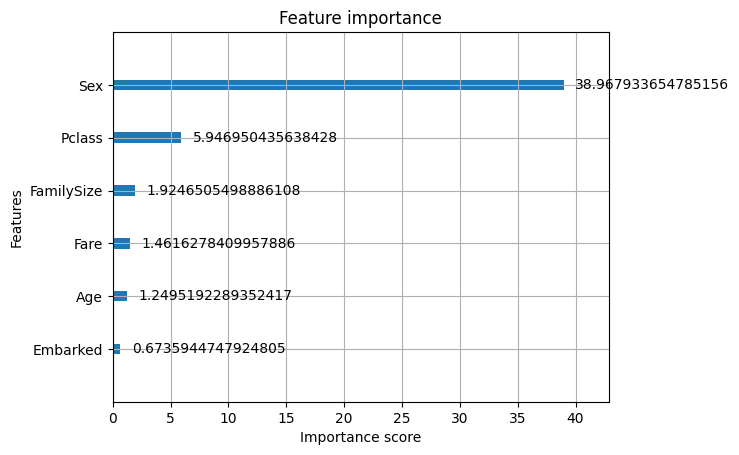

In [36]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Plot feature importance based on 'weight' (default), 'gain', or 'cover'
plot_importance(model, importance_type='gain', max_num_features=15)
plt.show()

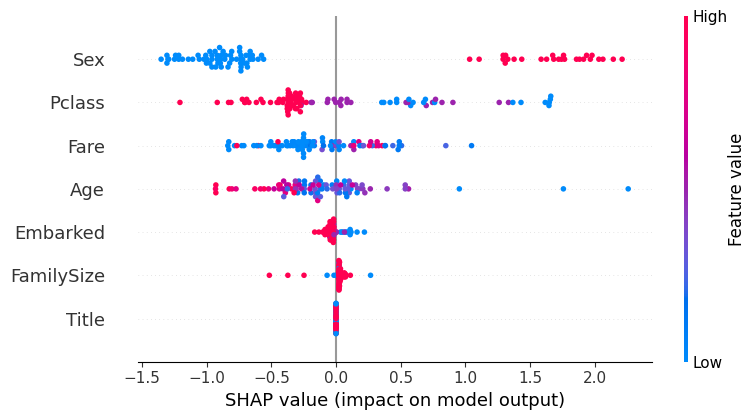

In [37]:
import shap

# Create explainer and calculate values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_fold)

# Visualize
shap.summary_plot(shap_values, X_test_fold)

In [38]:
# Dump model to text with statistics
model.get_booster().dump_model('model.txt', with_stats=True)

# Read and parse the file to extract split patterns
import re
with open('model.txt', 'r') as f:
    txt_model = f.read()

# Extract patterns like [f2<2.45]
splits = re.findall(r'\[f([0-9]+)<([0-9.e-]+)\]', txt_model)
print(splits)

[]


In [49]:
test_df = pd.read_csv('../data/raw/test.csv')
passengerId = test_df['PassengerId']
test_df = build_features(test_df)
preds = model.predict(test_df)
submission = pd.DataFrame({
    'PassengerId': passengerId,
    'Survived': preds
})
submission.head()
submission.to_csv('../data/raw/gender_submission.csv', index=False)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.4s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.9s
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:    1.6s
[Parallel(n_jobs=8)]: Done 1100 out of 1100 | elapsed:    2.2s finished


In [40]:

import mlflow
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, recall_score, f1_score

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare features for training:
    - drop Name, Ticket, Fare, and Cabin
    - fill missing cells of Age and Embarke
    - combine SibSp and Parch into 1 column FamilySize
    - split age to 5 groups: Infant, child, Teenager, Adult, and Senior (0-4)
    - encode categorical columns: Sex, Embarked, PClass
    - add 2 significant indicators: is_infant_or_female, is_family_size_2_to_4_or_upper_class
    """
    
    df[['Title', 'LastName']] = df['Name'].apply(lambda x: pd.Series(extract_title_and_last_name(x))).astype('category')
    
    # Standardize titles
    title_mapping = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
    df['Title'] = df['Title'].map(title_mapping)

    # Create mask for title replacement
    title_mask = ~df['Title'].isin(['Mr', 'Miss', 'Mrs', 'Master'])
    df.loc[title_mask, 'Title'] = df.loc[title_mask, 'Sex'].map({'male': 'Mr', 'female': 'Mrs'})
    df['Title'] = df['Title'].astype('category')
    df['Title'] = df['Title'].map({'Miss': 0, 'Mrs': 1, 'Master': 2, 'Mr': 3}).astype(int)
    
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['Fare'] = df['Fare'] * df['FamilySize'].astype(float)
    
    df['FamilySize'] = (pd.cut(df['FamilySize'], bins=[0, 1, 5, np.inf], labels=['Solo', 'Average', 'Large']))
    df['FamilyID'] = df['LastName'].astype(str) + df['FamilySize'].astype(str)
    df['FamilySize'] = df['FamilySize'].map({'Average': 0, 'Solo': 1, 'Large': 2}).astype(int)
    # df['is_solo'] = (df['FamilySize'] == 1).astype(int)
    
    df = df.fillna({'Age': df.groupby(['Title', 'Pclass'], observed=False)['Age'].transform('median')})
    df = df.fillna({'Embarked': df.groupby(['FamilyID', 'Pclass'], observed=False)['Embarked'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    df = df.fillna({'Embarked': df.groupby(['Pclass'], observed=False)['Embarked'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    df = df.fillna({'Cabin': df.groupby(['FamilyID', 'Pclass'], observed=False)['Cabin'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    df = df.fillna({'Cabin': df.groupby(['Pclass', 'Embarked'], observed=False)['Cabin'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    df = df.fillna({'Cabin': df.groupby(['Pclass'], observed=False)['Cabin'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)})
    
    # df['Age'] = pd.cut(df['Age'], bins=[0, 6, 12, 25, 65, np.inf], labels=[0, 1, 2, 3, 4])
    # df['Title'] = df['Title'].map(lambda x: 0 if x == 'Mr' else (1 if x == 'Mrs' else 2))
    
    if 'Sex' in df.columns:
        df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2}).astype(int)
    df['Cabin'] = df['Cabin'].map(lambda x: ord(x[0]) - ord('A')).astype(int)   
    if 'Pclass' in df.columns:
        df['Pclass'] = df['Pclass'] - 1
    
    df = df.drop(['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'LastName', 'FamilyID'], axis=1)

    return df

df = pd.read_csv('../data/raw/train.csv')
df = build_features(df)

In [ ]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from mlxtend.classifier import StackingCVClassifier
from sklearn.model_selection import cross_val_score
import sklearn

# sklearn.set_config(enable_metadata_routing=True)

# print(df.dtypes)

# target_col = 'Survived'

# X = df.drop(columns=[target_col])
# y = df[target_col]

# train_set_X, holdout_set_X, train_set_y, holdout_set_y = train_test_split(
#     X, 
#     y,
#     train_size=0.7, 
#     shuffle=True, 
#     random_state=0
# )

# # Define base models
# base_xgb = XGBClassifier(
#     n_estimators=300,
#     learning_rate=0.1,
#     max_depth=7,
#     random_state=42,
#     n_jobs=-1,
#     enable_categorical=True,
#     eval_metric="logloss"
# )

# bagging = BaggingClassifier(
#     estimator=base_xgb, 
#     n_estimators=100, 
#     max_samples=0.8,  # Each estimator sees 80% of the data
#     random_state=1
# )
# rfc = RandomForestClassifier(random_state=1)

# # Define meta-classifier
# lr = LogisticRegression()

# # Initialize StackingCVClassifier
# sclf = StackingCVClassifier(
#     classifiers=[rfc, bagging],
#     meta_classifier=lr,
#     random_state=42,
#     cv=3
# )

# sclf.fit(X, y)
# with mlflow.start_run():
#     # Define K-Fold
#     kf = KFold(n_splits=10, shuffle=True, random_state=42)
    
#     # Lists to store metrics for each fold
#     accuracies = []
#     recalls = []
#     f1s = []
#     models = []
    
#     # Loop through each fold
#     for fold, (train_index, test_index) in enumerate(kf.split(X)):
#         X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
#         y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
        
#         eval_set = [(X_train_fold, y_train_fold), (X_test_fold, y_test_fold)]
        
#         # Train model
#         model = stacked_model
#         model.fit(X_train_fold, y_train_fold)
#         # model.fit(X_train_fold, y_train_fold)
#         preds = model.predict(X_test_fold)
        
#         models.append(model)
#         # Calculate metrics
#         acc = accuracy_score(y_test_fold, preds)
#         rec = recall_score(y_test_fold, preds)
#         f1 = f1_score(y_test_fold, preds)
        
#         # Store metrics
#         accuracies.append(acc)
#         recalls.append(rec)
#         f1s.append(f1)
        
#         # Log metrics for this fold
#         mlflow.log_metric(f"accuracy_fold", acc, step=fold)
#         mlflow.log_metric(f"recall_fold", rec, step=fold)
    
#     # Log average and standard deviation
#     mlflow.log_metric("accuracy_mean", np.mean(accuracies))
#     mlflow.log_metric("accuracy_std", np.std(accuracies))
#     mlflow.log_metric("recall_mean", np.mean(recalls))
#     mlflow.log_metric("recall_std", np.std(recalls))
    
#     # Log parameters and dataset
#     mlflow.log_param("n_estimators", 300)
#     train_ds = mlflow.data.from_pandas(df, source="training_data")
#     mlflow.log_input(train_ds, context="training")
    
#     print(f"K-Fold Complete. Avg F1 Score: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}. Avg Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}, Avg Recall: {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")

Survived        int64
Pclass          int64
Sex             int64
Age           float64
Fare          float64
Cabin           int64
Embarked        int64
Title           int64
FamilySize      int64
dtype: object


KeyboardInterrupt: 

In [ ]:
test_df = pd.read_csv('../data/raw/test.csv')
passengerId = test_df['PassengerId']
test_df = build_features(test_df)
preds = sclf.predict(test_df)
submission = pd.DataFrame({
    'PassengerId': passengerId,
    'Survived': preds
})
submission.head()
submission.to_csv('../data/raw/gender_submission.csv', index=False)